[1.41421356 1.41421356]


Enter the length of time for the simulation:  10000


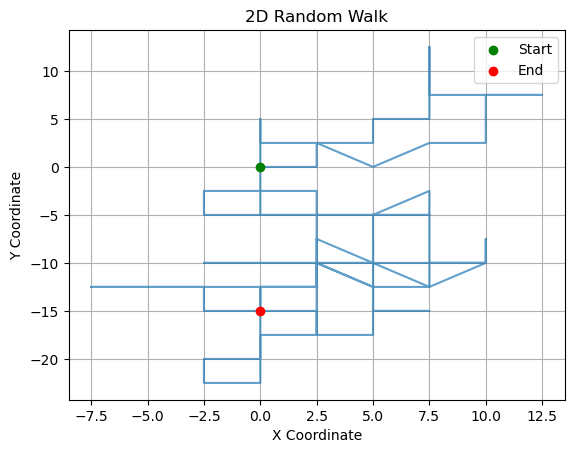

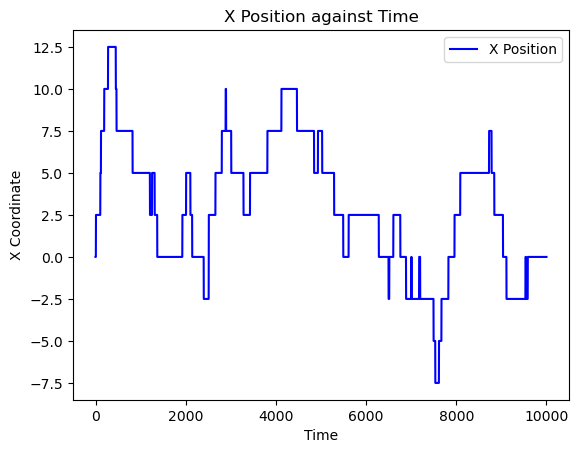

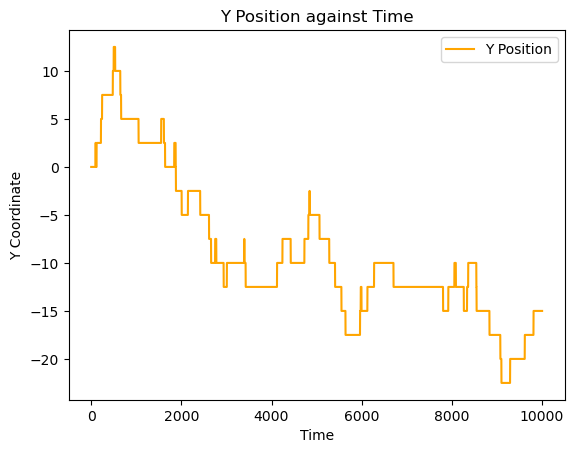

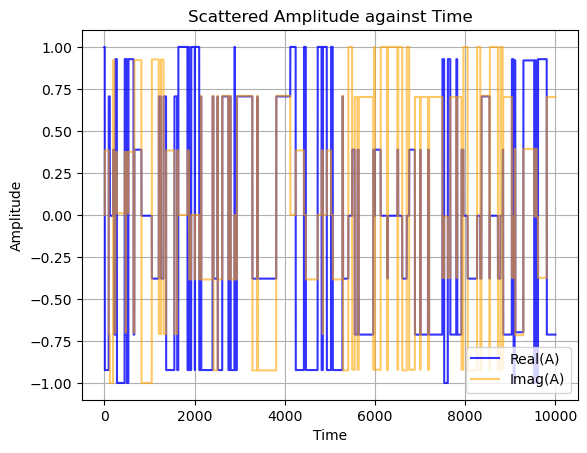

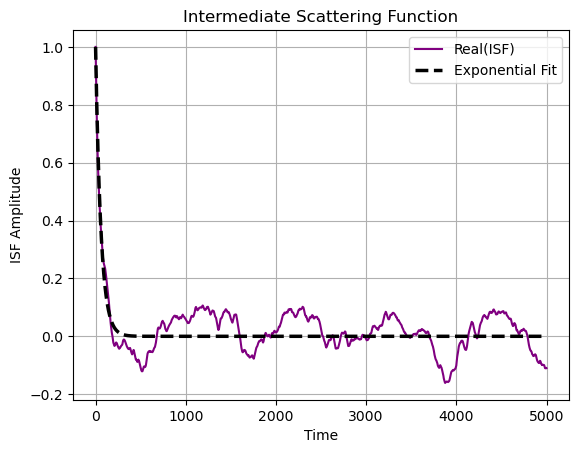

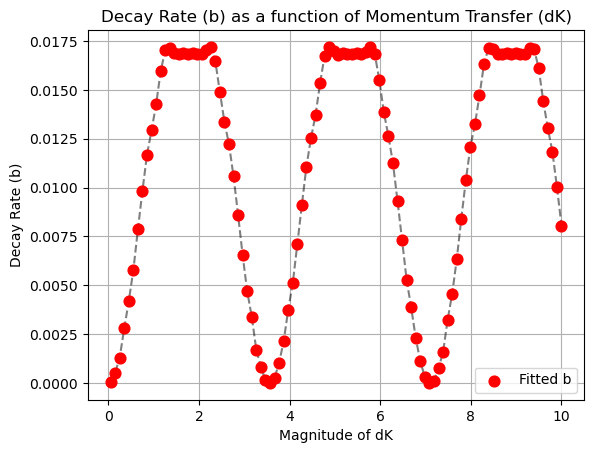

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Define coordinates
x=0
y=0
# Create array for storing coordinates
xstore = [x]
ystore = [y]
tstore = [0]
Sstore = [1]

# Form factor
F = 1

# Momentum transfer
magdK = 2
direction = np.array([1,1])
currentmag = np.linalg.norm(direction)
dK = magdK * (direction / currentmag)
print(dK)


# Enter length of time for the simulation
t = int(input("Enter the length of time for the simulation: "))
# Probability of hopping
Phop = 0.01
hopratio = 0.9
# Possible hops that could be taken
hops = [(2.5,0),(-2.5,0),(0,2.5),(0,-2.5)]
hops2NN = [(2.5,2.5), (-2.5,2.5), (2.5,-2.5), (-2.5,-2.5)]

# Loop to calcualte position at each time interval
for i in range(t):
    if random.random() < Phop:
        if random.random() < hopratio:
            dx,dy = random.choice(hops)
        else:
            dx,dy = random.choice(hops2NN)
        x += dx
        y += dy
    # Modify array for coordinates
    xstore.append(x)
    ystore.append(y)
    tstore.append(i+1)
    S = np.exp(-1j * np.dot(dK, [x,y]))
    Sstore.append(S)

# Scattering amplitude
A = F * np.array(Sstore)
Areal = np.real(A)
Aimag = np.imag(A)

# Fast fourier transforms to find the autocorrelation function
Afft = np.fft.fft(A)

# Power spectral density
PS = np.abs(Afft)**2

autocorr = np.fft.ifft(PS)

# Find timebase for the intermediate scattering function
ISF = autocorr / autocorr[0]
halflen = len(A) // 2
ISFhalf = ISF[:halflen]
timebase = range(halflen)

# Plot and label everything
plt.plot(xstore, ystore, marker = '', linestyle = '-', alpha = 0.7)
plt.scatter(0,0, color = 'green', label = 'Start', zorder = 5)
plt.scatter(x,y, color = 'red', label = 'End', zorder = 5)
plt.title("2D Random Walk")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(tstore,xstore, color = 'blue', label = 'X Position')
plt.title("X Position against Time")
plt.xlabel("Time")
plt.ylabel("X Coordinate")
plt.legend()
plt.show()

plt.plot(tstore,ystore, color = 'orange', label = 'Y Position')
plt.title("Y Position against Time")
plt.xlabel("Time")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

plt.plot(tstore, Areal, color = 'blue', label = 'Real(A)', alpha=0.8)
plt.plot(tstore, Aimag, color = 'orange', label = 'Imag(A)', alpha=0.6)
plt.title("Scattered Amplitude against Time")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Fit an exponential decay curve to the simulation
def expdecay(t, b):
    return np.exp(-b * t)

tdata = np.array(timebase)
ydata = np.real(ISFhalf)

popt, pcov = curve_fit(expdecay, tdata, ydata, p0 = [0.001], bounds = (0,np.inf))

boptimal = popt[0]
berror = np.sqrt(np.diag(pcov))[0]

fittedcurve = expdecay(tdata, boptimal)

plt.plot(timebase, np.real(ISFhalf), color = 'purple', label = 'Real(ISF)')
plt.plot(tdata, fittedcurve, color = 'black', linestyle = '--', linewidth = 2.5, label = "Exponential Fit")
plt.title("Intermediate Scattering Function")
plt.xlabel("Time")
plt.ylabel("ISF Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# We now want to do the last section over many dK values and look at the relationship between b and dK
xarr = np.array(xstore)
yarr = np.array(ystore)

magdKlist = np.linspace(0.05,10,100)

bvalues = []
dKvalues = []

# Iterate through dK values
for mag in magdKlist:
    currentdK = mag * (direction / currentmag)
    Sarr = np.exp(-1j * ((currentdK[0] * xarr) + (currentdK[1] * yarr)))
    Aarr = F * Sarr
    
    Afftarr = np.fft.fft(Aarr)
    PSarr = np.abs(Afftarr)**2
    autocorrarr = np.fft.ifft(PSarr)
    
    ISFarr = autocorrarr / autocorrarr[0]
    ISFhalfarr = ISFarr[:halflen]
    ydataarr = np.real(ISFhalfarr)
    
    try:
        poptarr, _ = curve_fit(expdecay, tdata, ydataarr, p0=[0.001], bounds=(0, np.inf))
        bvalues.append(poptarr[0])
        dKvalues.append(mag)
    except RuntimeError:
        pass


# Plot the b values as a function of varying dK    
plt.plot(dKvalues, bvalues, color = 'black', linestyle = '--', alpha = 0.5)
plt.scatter(dKvalues, bvalues, color = 'red', zorder = 5, s = 60, label = 'Fitted b')
plt.title("Decay Rate (b) as a function of Momentum Transfer (dK)")
plt.xlabel("Magnitude of dK")
plt.ylabel("Decay Rate (b)")
plt.legend()
plt.grid(True)
plt.show()